In [3]:
import openmm.app as app
import openmm
import openmm.unit as unit
from openmmtools.mcmc import HMCMove, GHMCMove
from openmmtools.states import ThermodynamicState, SamplerState
from openmmtools.cache import ContextCache
import mdtraj as md
from openmmforcefields.generators import GAFFTemplateGenerator
from openff.toolkit.topology import Molecule
from openff.toolkit.utils import RDKitToolkitWrapper
import matplotlib.pyplot as plt
import numpy as np
import openmm.unit as unit
from openmm import XmlSerializer
from rdkit.Chem import AllChem

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



In [4]:
class HMCMoveWithStats(HMCMove):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.n_accepted = 0  # Number of accepted steps
        self.n_proposed = 0  # Number of attempted steps
        self.current_acceptance = 0.0  # Current acceptance state

    @property
    def fraction_accepted(self):
        """Ratio between accepted over attempted moves (read-only)."""
        if self.n_proposed == 0:
            return float('nan')
        return float(self.n_accepted) / self.n_proposed
    
    @property
    def statistics(self):
        """The acceptance statistics as a dictionary."""
        return dict(n_accepted=self.n_accepted, n_proposed=self.n_proposed)

    def reset_statistics(self):
        """Reset the internal statistics of number of accepted and attempted moves."""
        self.n_accepted = 0
        self.n_proposed = 0

    def _after_integration(self, context, thermodynamic_state):
        """Capture the acceptance statistics after integration."""
        integrator = context.getIntegrator()
        hmc_global_variables = {integrator.getGlobalVariableName(i): i for i in range(integrator.getNumGlobalVariables())}
        
        n_accepted = integrator.getGlobalVariable(hmc_global_variables['naccept'])
        n_proposed = integrator.getGlobalVariable(hmc_global_variables['ntrials'])

        self.current_acceptance = n_accepted

        # print(f"Accepted: {n_accepted}, Proposed: {n_proposed}")

        self.n_accepted += n_accepted
        self.n_proposed += n_proposed
        # print(f"Accepted: {self.n_accepted}, Proposed: {self.n_proposed}")

In [3]:
# Load molecule from SMILES and generate conformers
smiles = 'CCCCC'  # Pentane
off_molecule = Molecule.from_smiles(smiles)
off_molecule.generate_conformers(n_conformers=1, toolkit_registry=RDKitToolkitWrapper())

In [4]:
# Get the rdkit molecule
rdkit_mol = off_molecule.to_rdkit()

# Embed and generate a random conformation
AllChem.EmbedMolecule(rdkit_mol)
AllChem.UFFOptimizeMolecule(rdkit_mol)

# Set specific dihedral angles
conf = rdkit_mol.GetConformer()
from rdkit.Chem.rdMolTransforms import SetDihedralDeg

# Set dihedrals to eclipsed conformations (high energy)
SetDihedralDeg(conf, 0, 1, 2, 3, 0.0)   # Dihedral 1
SetDihedralDeg(conf, 1, 2, 3, 4, 100.0)   # Dihedral 2

# Convert back to OpenFF Molecule
off_molecule = Molecule.from_rdkit(rdkit_mol, allow_undefined_stereo=True)

# Save this high-energy conformer to file
pdb_filename = "pentane_highE.pdb"
off_molecule.to_file(pdb_filename, "PDB")

# # Save to a PDB file for OpenMM compatibility
# pdb_filename = "pentane.pdb"
# off_molecule.to_file(pdb_filename, "PDB")

In [5]:
# Load PDB file
pdb = app.PDBFile(pdb_filename)

# Create GAFF template generator and register it
gaff_generator = GAFFTemplateGenerator(molecules=[off_molecule])
forcefield = app.ForceField("gaff.xml")         # amber99sbildn.xml can also be used
forcefield.registerTemplateGenerator(gaff_generator.generator)

# Create a Modeller to handle missing hydrogens if needed
modeller = app.Modeller(pdb.topology, pdb.positions)

In [6]:
# Create system with constraints and force field parameters
system = forcefield.createSystem(
    modeller.topology, 
    nonbondedMethod=app.NoCutoff, 
    constraints=app.AllBonds
)

# Create a thermodynamic state
thermo_state = ThermodynamicState(system, temperature=300 * unit.kelvin)

# Set up sampler state
sampler_state = SamplerState(modeller.positions)

# Create HMC move
# hmc_move = HMCMove(timestep=0.002 * unit.picoseconds, n_steps=80, reassign_velocities=True)
# hmc_move = GHMCMove(timestep=0.002 * unit.picoseconds, n_steps=80, reassign_velocities=True)
hmc_move = HMCMoveWithStats(timestep=2 * unit.femtoseconds, n_steps=80, reassign_velocities=True)

# Context cache (for efficiency)
cache = ContextCache()

In [7]:
# Print system parameters
print("GAFF Parameters:")

# Bonds
print("\nBonds:")
for i in range(system.getNumForces()):
    force = system.getForce(i)
    if isinstance(force, openmm.HarmonicBondForce):
        for j in range(force.getNumBonds()):
            p1, p2, length, k = force.getBondParameters(j)
            print(f"Atoms {p1}-{p2}: Length = {length}, k = {k}")

# Angles
print("\nAngles:")
for i in range(system.getNumForces()):
    force = system.getForce(i)
    if isinstance(force, openmm.HarmonicAngleForce):
        for j in range(force.getNumAngles()):
            p1, p2, p3, angle, k = force.getAngleParameters(j)
            print(f"Atoms {p1}-{p2}-{p3}: Angle = {angle}, k = {k}")

# Torsions (Dihedrals)
print("\nDihedrals:")
for i in range(system.getNumForces()):
    force = system.getForce(i)
    if isinstance(force, openmm.PeriodicTorsionForce):
        for j in range(force.getNumTorsions()):
            p1, p2, p3, p4, periodicity, phase, k = force.getTorsionParameters(j)
            print(f"Atoms {p1}-{p2}-{p3}-{p4}: Periodicity = {periodicity}, Phase = {phase}, k = {k}")

# Nonbonded interactions (Lennard-Jones and Electrostatics)
print("\nNonbonded Interactions:")
for i in range(system.getNumForces()):
    force = system.getForce(i)
    if isinstance(force, openmm.NonbondedForce):
        for j in range(force.getNumParticles()):
            charge, sigma, epsilon = force.getParticleParameters(j)
            print(f"Atom {j}: Charge = {charge}, Sigma = {sigma}, Epsilon = {epsilon}")

# Save system parameters to an XML file for inspection
with open("gaff_system.xml", "w") as f:
    f.write(XmlSerializer.serialize(system))
    print("\nSystem parameters saved to 'gaff_system.xml'")

GAFF Parameters:

Bonds:

Angles:
Atoms 0-1-2: Angle = 1.93085775148 rad, k = 528.94128 kJ/(mol rad**2)
Atoms 0-1-8: Angle = 1.92073484182 rad, k = 388.02416 kJ/(mol rad**2)
Atoms 0-1-9: Angle = 1.92073484182 rad, k = 388.02416 kJ/(mol rad**2)
Atoms 1-0-5: Angle = 1.92073484182 rad, k = 388.02416 kJ/(mol rad**2)
Atoms 1-0-6: Angle = 1.92073484182 rad, k = 388.02416 kJ/(mol rad**2)
Atoms 1-0-7: Angle = 1.92073484182 rad, k = 388.02416 kJ/(mol rad**2)
Atoms 1-2-3: Angle = 1.93085775148 rad, k = 528.94128 kJ/(mol rad**2)
Atoms 1-2-10: Angle = 1.92073484182 rad, k = 388.02416 kJ/(mol rad**2)
Atoms 1-2-11: Angle = 1.92073484182 rad, k = 388.02416 kJ/(mol rad**2)
Atoms 2-1-8: Angle = 1.92073484182 rad, k = 388.02416 kJ/(mol rad**2)
Atoms 2-1-9: Angle = 1.92073484182 rad, k = 388.02416 kJ/(mol rad**2)
Atoms 2-3-4: Angle = 1.93085775148 rad, k = 528.94128 kJ/(mol rad**2)
Atoms 2-3-12: Angle = 1.92073484182 rad, k = 388.02416 kJ/(mol rad**2)
Atoms 2-3-13: Angle = 1.92073484182 rad, k = 388.0241

In [8]:
# Create context manually
integrator = openmm.VerletIntegrator(2.0 * unit.femtoseconds)  # dummy integrator
platform = openmm.Platform.getPlatformByName("CUDA")      # or use "CPU" or "CUDA" if available
context = openmm.Context(system, integrator, platform)

# Set positions from sampler_state
context.setPositions(sampler_state.positions)

# Compute and print potential energy
state = context.getState(getEnergy=True)
initial_energy = state.getPotentialEnergy().value_in_unit(unit.kilojoules_per_mole)
print(f"Initial energy: {initial_energy:.3f} kJ/mol")

# Clean up
del context, integrator


Initial energy: 180.769 kJ/mol


In [9]:
# Store energies and sampled positions
energies = [initial_energy]
sampled_positions = []

# Atom indices for the two main dihedrals in pentane (assuming standard numbering)
dihedral1_atoms = [0, 1, 2, 3]  # First dihedral
dihedral2_atoms = [1, 2, 3, 4]  # Second dihedral

# Run HMC Sampling
num_iterations = 100000
i = 0
while i < num_iterations:

    hmc_move.apply(thermo_state, sampler_state, cache)

    # Reject if the move is not accepted
    if hmc_move.current_acceptance == 0.0:
        # print(f"Move rejected at step {i}.")
        continue

    # Record energy
    energy = sampler_state.potential_energy.value_in_unit(unit.kilojoules_per_mole)
    energies.append(energy)

    # Store positions (in nanometers)
    sampled_positions.append(sampler_state.positions.value_in_unit(unit.nanometer))

    # Print energy every 100 steps
    if i % 100 == 0:
        print(f"Step {i}, Energy: {energy:.3f} kJ/mol")
    
    i += 1

print("HMC Sampling complete.")

Step 0, Energy: 82.584 kJ/mol
Step 100, Energy: 37.133 kJ/mol
Step 200, Energy: 40.444 kJ/mol
Step 300, Energy: 53.730 kJ/mol
Step 400, Energy: 47.238 kJ/mol
Step 500, Energy: 44.924 kJ/mol
Step 600, Energy: 44.049 kJ/mol
Step 700, Energy: 35.389 kJ/mol
Step 800, Energy: 35.978 kJ/mol
Step 900, Energy: 45.960 kJ/mol
Step 1000, Energy: 52.261 kJ/mol
Step 1100, Energy: 37.177 kJ/mol
Step 1200, Energy: 46.141 kJ/mol
Step 1300, Energy: 37.240 kJ/mol
Step 1400, Energy: 58.191 kJ/mol
Step 1500, Energy: 35.264 kJ/mol
Step 1600, Energy: 50.928 kJ/mol
Step 1700, Energy: 67.710 kJ/mol
Step 1800, Energy: 46.021 kJ/mol
Step 1900, Energy: 43.273 kJ/mol
Step 2000, Energy: 34.287 kJ/mol
Step 2100, Energy: 34.431 kJ/mol
Step 2200, Energy: 53.075 kJ/mol
Step 2300, Energy: 43.901 kJ/mol
Step 2400, Energy: 49.612 kJ/mol
Step 2500, Energy: 53.332 kJ/mol
Step 2600, Energy: 43.414 kJ/mol
Step 2700, Energy: 38.982 kJ/mol
Step 2800, Energy: 45.702 kJ/mol
Step 2900, Energy: 38.417 kJ/mol
Step 3000, Energy: 33.

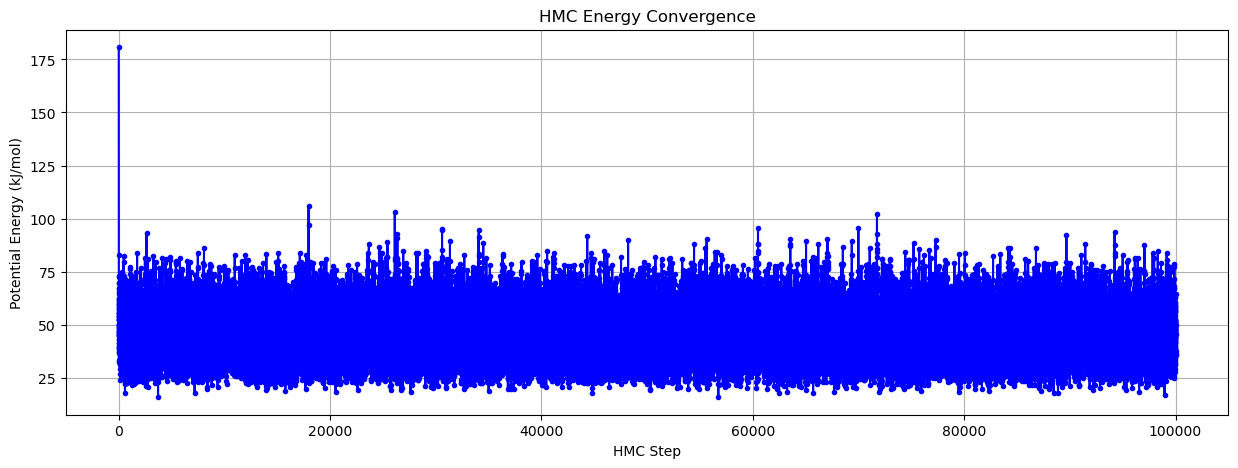

In [10]:
# Convert sampled positions to a NumPy array
sampled_positions = np.array(sampled_positions)  # Shape: (num_iterations, num_atoms, 3)

# Plot energy over iterations
plt.figure(figsize=(15, 5))
plt.plot(np.arange(num_iterations+1), energies, marker='o', linestyle='-', color='b', markersize=3)
plt.xlabel("HMC Step")
plt.ylabel("Potential Energy (kJ/mol)")
plt.title("HMC Energy Convergence")
plt.grid(True)
plt.show()

# Optional: Save positions to a file for later analysis
np.save("hmc_samples.npy", sampled_positions)

First frame of the trajectory:
[[-0.20658016  0.03843533  0.01300293]
 [-0.06496735 -0.00154929 -0.03173499]
 [ 0.03385358  0.04134592  0.07803233]
 [ 0.02986981 -0.04098449  0.20787944]
 [ 0.11578043 -0.16855331  0.20781897]
 [-0.21340749  0.14711964  0.02623923]
 [-0.22955975 -0.02176557  0.1017829 ]
 [-0.2714141   0.00961484 -0.07066325]
 [-0.0467582   0.05914306 -0.12128364]
 [-0.06730724 -0.1102903  -0.04601828]
 [-0.00796125  0.14074327  0.09817642]
 [ 0.13234882  0.06199041  0.03436778]
 [-0.06482293 -0.08516707  0.2412753 ]
 [ 0.08039393  0.01803099  0.28532997]
 [ 0.21920916 -0.14236571  0.18230823]
 [ 0.07006709 -0.22833982  0.12800698]
 [ 0.1258972  -0.21474761  0.30680296]]


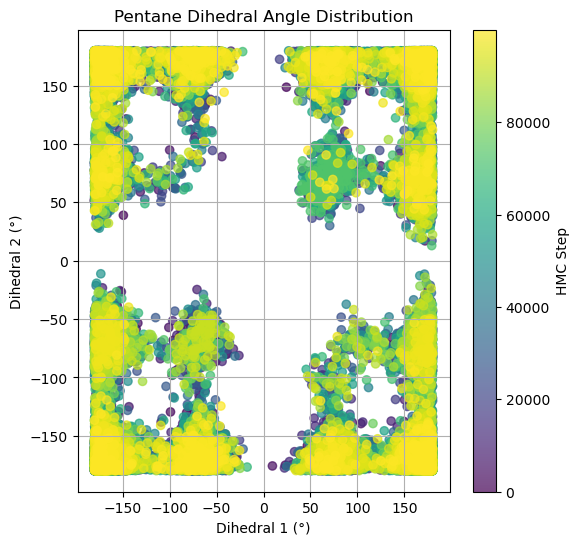

In [ ]:
# Convert sampled positions to an MDTraj Trajectory object
topology = md.Topology.from_openmm(modeller.topology)
trajectory = md.Trajectory(sampled_positions, topology)

# print the first frame of the trajectory
print("First frame of the trajectory:")
print(trajectory.xyz[0])

# Compute dihedral angles (in radians)
dihedral1_angles = md.compute_dihedrals(trajectory, [dihedral1_atoms])
dihedral2_angles = md.compute_dihedrals(trajectory, [dihedral2_atoms])

# Convert angles to degrees
dihedral1_angles = np.degrees(dihedral1_angles).flatten()
dihedral2_angles = np.degrees(dihedral2_angles).flatten()

# Plot dihedral angles
plt.figure(figsize=(8, 6))
plt.scatter(dihedral1_angles, dihedral2_angles, c=np.arange(num_iterations), cmap='viridis', alpha=0.7)
plt.colorbar(label="HMC Step")
plt.xlabel("Dihedral 1 (°)")
plt.ylabel("Dihedral 2 (°)")
plt.title("Pentane Dihedral Angle Distribution")
plt.grid(True)
plt.show()

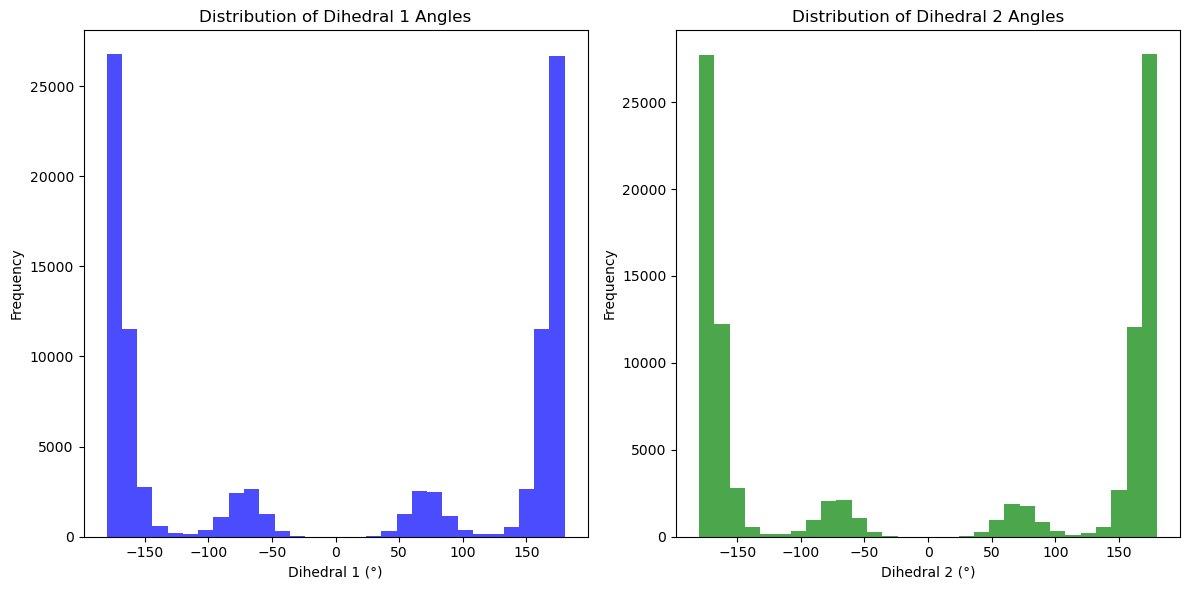

In [12]:
# plot histogram of dihedral angles
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(dihedral1_angles, bins=30, color='blue', alpha=0.7)
plt.xlabel("Dihedral 1 (°)")
plt.ylabel("Frequency")
plt.title("Distribution of Dihedral 1 Angles")
plt.subplot(1, 2, 2)
plt.hist(dihedral2_angles, bins=30, color='green', alpha=0.7)
plt.xlabel("Dihedral 2 (°)")
plt.ylabel("Frequency")
plt.title("Distribution of Dihedral 2 Angles")
plt.tight_layout()
plt.show()

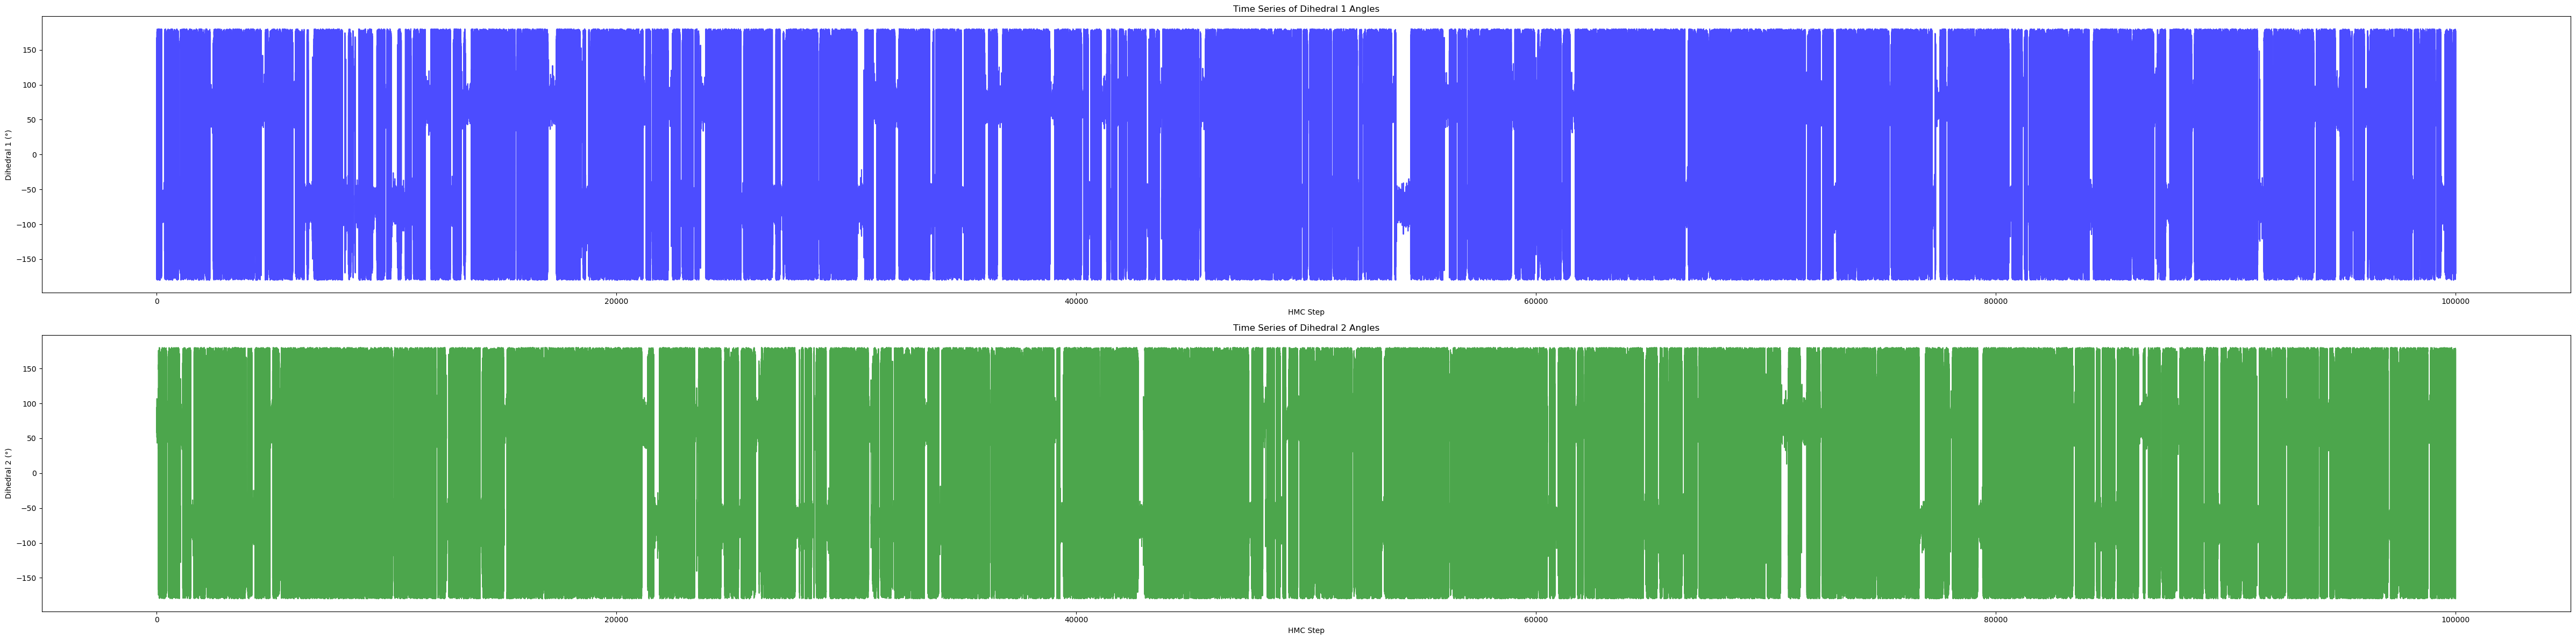

In [13]:
# plot time series of dihedral angles
plt.figure(figsize=(48, 12))
plt.subplot(2, 1, 1)
plt.plot(dihedral1_angles[:], color='blue', alpha=0.7)
plt.xlabel("HMC Step")
plt.ylabel("Dihedral 1 (°)")
plt.title("Time Series of Dihedral 1 Angles")
plt.subplot(2, 1, 2)
plt.plot(dihedral2_angles[:], color='green', alpha=0.7)
plt.xlabel("HMC Step")
plt.ylabel("Dihedral 2 (°)")
plt.title("Time Series of Dihedral 2 Angles")
plt.tight_layout()
plt.show()

In [14]:
# Extract atom names
atom_names = [atom.element.symbol for atom in modeller.topology.atoms()]

# Write XYZ file
xyz_filename = "hmc_trajectory.xyz"
with open(xyz_filename, "w") as xyz_file:
    for i in range(num_iterations):
        xyz_file.write(f"{len(atom_names)}\n")  # Number of atoms
        xyz_file.write(f"Frame {i}\n")  # Frame header

        for j, atom_name in enumerate(atom_names):
            x, y, z = sampled_positions[i, j]*10  # Get coordinates
            xyz_file.write(f"{atom_name} {x:.5f} {y:.5f} {z:.5f}\n")  # Write line

print(f"HMC trajectory saved as {xyz_filename}.")


HMC trajectory saved as hmc_trajectory.xyz.


In [15]:
print(hmc_move.fraction_accepted)
print(hmc_move.statistics)

0.9200563074460157
{'n_accepted': 100000.0, 'n_proposed': 108689.0}


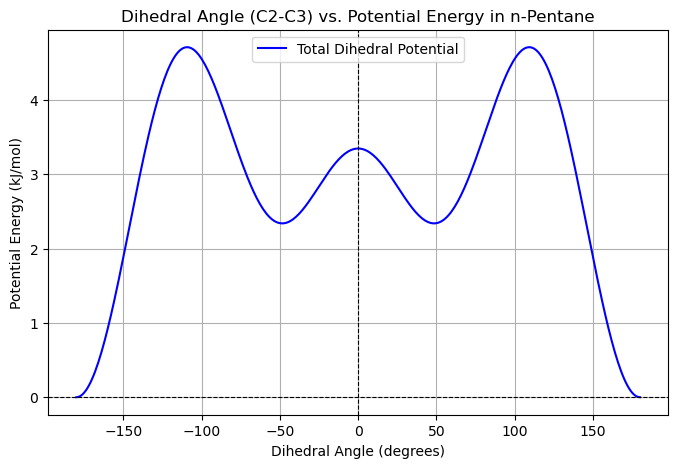

In [16]:
# Define dihedral parameters (from your data)
dihedrals = [
    {"periodicity": 3, "phase": 0.0, "k": 0.54392},
    {"periodicity": 2, "phase": np.pi, "k": 1.21336},
    {"periodicity": 1, "phase": 0.0, "k": 0.46024},
    {"periodicity": 3, "phase": 0.0, "k": 0.33472},  # Hydrogens
    {"periodicity": 3, "phase": 0.0, "k": 0.33472},  # Hydrogens
]

# Define dihedral angles (from -180 to 180 degrees)
angles = np.linspace(-np.pi, np.pi, 360)  # Radians

# Compute total potential energy for each angle
V_total = np.zeros_like(angles)

for dih in dihedrals:
    k, p, phi = dih["k"], dih["periodicity"], dih["phase"]
    V_total += k * (1 + np.cos(p * angles - phi))

# Plot the potential energy as a function of dihedral angle
plt.figure(figsize=(8, 5))
plt.plot(np.degrees(angles), V_total, label="Total Dihedral Potential", color="b")
plt.xlabel("Dihedral Angle (degrees)")
plt.ylabel("Potential Energy (kJ/mol)")
plt.title("Dihedral Angle (C2-C3) vs. Potential Energy in n-Pentane")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.legend()
plt.grid()

plt.show()


#### RUN NEXT PARTS FOR CONSTRUCTING TRANSITION MATRIX

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MeanShift, DBSCAN, KMeans
import openmm.app as app
import mdtraj as md
from scipy.interpolate import griddata

In [2]:
def compute_dihedral_angles(trajectory, dihedral1_atoms, dihedral2_atoms):
    # Compute dihedral angles (in radians)
    dihedral1_angles = md.compute_dihedrals(trajectory, [dihedral1_atoms])
    dihedral2_angles = md.compute_dihedrals(trajectory, [dihedral2_atoms])

    # Convert angles to degrees
    dihedral1_angles = np.degrees(dihedral1_angles).flatten()
    dihedral2_angles = np.degrees(dihedral2_angles).flatten()
    return np.column_stack((dihedral1_angles, dihedral2_angles))  # Shape: (num_samples, 2)

def transform_angles(angles):
    """
    Transform angles to (cos, sin) representation to account for periodicity.
    :param angles: Array of shape (num_samples, 2) with angles in degrees
    :return: Transformed array of shape (num_samples, 4)
    """
    return np.hstack([np.cos(np.radians(angles)), np.sin(np.radians(angles))])

def cluster_samples(dihedral_angles, n_clusters=5):
    transformed_angles = transform_angles(dihedral_angles)
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(transformed_angles)
    return labels, kmeans

def construct_transition_matrix(labels, n_clusters):
    """
    Constructs the transition probability matrix P from cluster labels.
    """
    P = np.zeros((n_clusters, n_clusters))
    for i in range(len(labels) - 1):
        P[labels[i]][labels[i+1]] += 1
        P[labels[i+1], labels[i]] += 1  # Symmetric transition
         
    # Normalize rows to get probabilities
    row_sums = P.sum(axis=1, keepdims=True)
    P = np.divide(P, row_sums, where=row_sums > 0)

    return P

def plot_clusters(dihedral_angles, labels, n_clusters):
    """
    Visualizes clusters in dihedral angle space.
    """
    cmap = plt.get_cmap('tab20', n_clusters)  # Distinct colors for each cluster
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(dihedral_angles[:, 0], dihedral_angles[:, 1], c=labels, cmap=cmap, alpha=0.7)
    plt.colorbar(scatter, ticks=range(n_clusters), label='Cluster Label')
    plt.xlabel('Dihedral Angle 1 (degrees)')
    plt.ylabel('Dihedral Angle 2 (degrees)')
    plt.title('Clustering of Dihedral Angles')
    plt.show()

def plot_transition_matrix(P):
    """
    Visualizes the transition probability matrix P.
    """
    plt.figure(figsize=(8, 6))
    plt.imshow(P, cmap='Blues', interpolation='nearest')
    plt.colorbar(label='Transition Probability')
    plt.xlabel('To State')
    plt.ylabel('From State')
    plt.title('Transition Probability Matrix')
    plt.show()

In [3]:
pdb_filename = "pentane_highE.pdb"
pdb = app.PDBFile(pdb_filename)
modeller = app.Modeller(pdb.topology, pdb.positions)

# Atom indices for the two main dihedrals in pentane (assuming standard numbering)
dihedral1_atoms = [0, 1, 2, 3]  # First dihedral
dihedral2_atoms = [1, 2, 3, 4]  # Second dihedral

sampled_positions = np.load("hmc_samples.npy")  # Load the sampled positions
# Convert sampled positions to an MDTraj Trajectory object
topology = md.Topology.from_openmm(modeller.topology)
trajectory = md.Trajectory(sampled_positions, topology)

dihedral_angles = compute_dihedral_angles(trajectory, dihedral1_atoms, dihedral2_atoms)
labels, kmeans = cluster_samples(dihedral_angles, n_clusters=400)
n_clusters = len(np.unique(labels))
cluster_centers = kmeans.cluster_centers_
P = construct_transition_matrix(labels, n_clusters)

In [4]:
# print the transition matrix
print("Cluster labels:")
print(labels)
print("Number of clusters:")
print(n_clusters)
print("Transition Matrix P:")
print(P)

Cluster labels:
[232 219 147 ... 126  85 267]
Number of clusters:
400
Transition Matrix P:
[[0.         0.         0.         ... 0.         0.00233645 0.        ]
 [0.         0.00136612 0.         ... 0.         0.00614754 0.        ]
 [0.         0.         0.01845018 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.03333333 0.         0.        ]
 [0.00063776 0.0057398  0.         ... 0.         0.00765306 0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


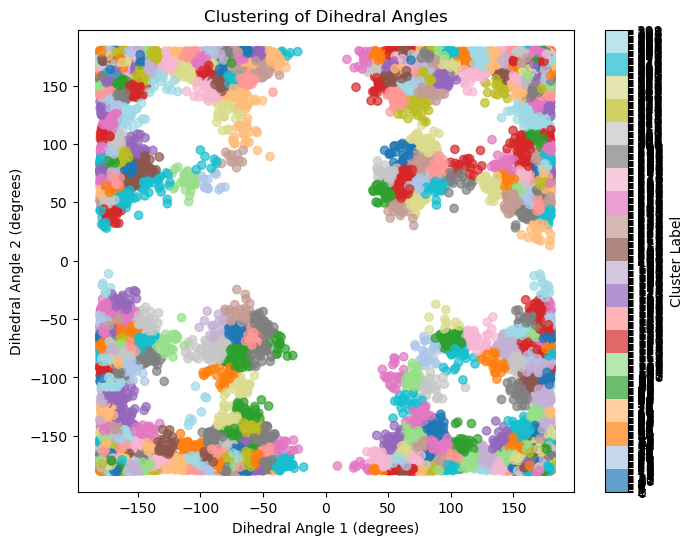

In [5]:
# Plot clusters
plot_clusters((dihedral_angles), labels, n_clusters)

In [6]:
# print all the cluster labels
for i in range(n_clusters):
    print(f"Cluster {i}:")
    print(np.where(labels == i)[0])

Cluster 0:
[  650   819   965  1422  2454  2458  2460  2633  3044  3048  3485  4432
  5614  5634  5824  6039  6299  6852  7341  9249  9370  9392  9747  9787
 10036 10122 10993 11001 11965 12098 14510 14514 15338 15437 16198 17720
 17750 18362 19319 19640 19976 22006 22429 23118 24839 24841 27252 27258
 27562 27651 29046 29495 29834 30144 31527 31617 31883 32464 32468 32740
 33293 34404 34515 34916 35309 35311 35365 36570 36874 37032 37847 38321
 38462 40343 40771 41323 41327 41392 42067 42079 42461 43222 43589 44146
 44407 45403 46195 46642 48471 48860 49257 49623 50045 50196 50588 50855
 51223 51439 51952 52370 52372 52674 54647 54653 55066 55959 56876 56965
 57279 57555 57557 57975 58301 58344 58548 58913 59352 60129 60724 62285
 62293 62436 63001 63009 63287 64077 64150 64595 65108 67302 67914 67916
 67987 67989 68000 68455 68479 68481 68487 68552 68688 69470 71402 71463
 71981 72697 73223 73704 73706 73789 74345 75443 75455 75459 76389 76392
 76394 77134 78337 78807 78820 79535 800

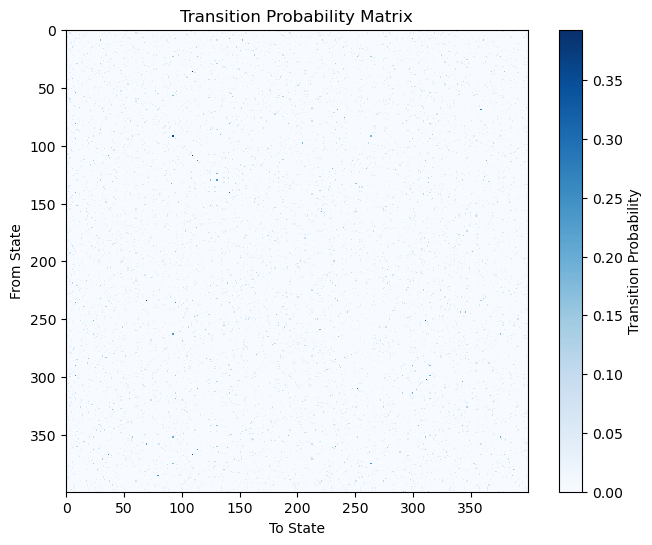

In [7]:
plot_transition_matrix(P)

In [8]:
# print sum of row of P
print(P.sum(axis=1))
print(P.sum(axis=0))
print(P.sum())

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.

In [9]:
def compute_eigenmodes(P):
    """
    Computes the eigenvalues and eigenvectors of the transition matrix P.
    Returns eigenvalues sorted in descending order and corresponding eigenvectors.
    """
    eigenvalues, eigenvectors = np.linalg.eig(P)

    # Sort eigenvalues (and corresponding eigenvectors) in descending order
    idx = np.argsort(-np.real(eigenvalues))  # Sort by largest real part
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    return eigenvalues, eigenvectors

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = compute_eigenmodes(P)

# Print the top eigenvalues
print("Eigenvalues of P:", eigenvalues[:])  # Show first 5 eigenvalues


Eigenvalues of P: [ 1.00000000e+00  9.82541215e-01  9.80453059e-01  9.78390454e-01
  9.77480213e-01  9.54975143e-01  9.47374035e-01  7.88581680e-01
  7.42185604e-01  7.13096467e-01  6.38006464e-01  5.39073904e-01
  5.37520104e-01  4.83420024e-01  4.51890481e-01  3.94435975e-01
  3.89428252e-01  3.79459290e-01  3.71710173e-01  3.59313717e-01
  3.37496523e-01  3.24059817e-01  3.08284901e-01  3.05483551e-01
  3.01229284e-01  2.94525223e-01  2.92464991e-01  2.86237521e-01
  2.78554018e-01  2.73147847e-01  2.63298224e-01  2.51744144e-01
  2.32672532e-01  2.23842042e-01  2.12583864e-01  1.93037396e-01
  1.91059815e-01  1.85447090e-01  1.77533234e-01  1.72933183e-01
  1.68591596e-01  1.67057476e-01  1.59260404e-01  1.49074003e-01
  1.47463585e-01  1.45125257e-01  1.40950513e-01  1.35430266e-01
  1.34253008e-01  1.28709513e-01  1.26944071e-01  1.25501520e-01
  1.24640345e-01  1.23524549e-01  1.21363328e-01  1.17087506e-01
  1.14398928e-01  1.13730839e-01  1.12314725e-01  1.10903737e-01
  1.095

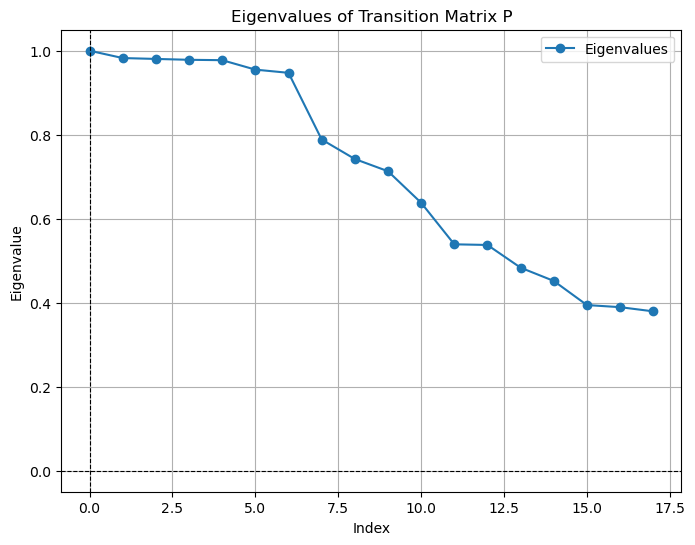

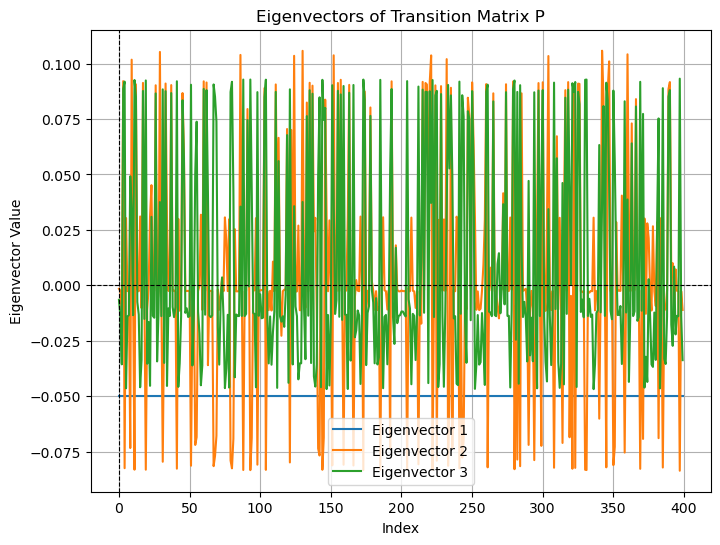

In [10]:
# visually show the eigenvalues
plt.figure(figsize=(8, 6))
plt.plot(np.real(eigenvalues[:18]), 'o-', label='Eigenvalues')
plt.xlabel('Index')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalues of Transition Matrix P')
plt.axhline(0, color='black', linewidth=0.8, linestyle="--")
plt.axvline(0, color='black', linewidth=0.8, linestyle="--")
plt.legend()
plt.grid()
plt.show()
# Plot eigenvectors
plt.figure(figsize=(8, 6))
for i in range(min(3, eigenvectors.shape[1])):
    plt.plot(np.real(eigenvectors[:, i]), label=f'Eigenvector {i+1}')
plt.xlabel('Index')
plt.ylabel('Eigenvector Value')
plt.title('Eigenvectors of Transition Matrix P')
plt.axhline(0, color='black', linewidth=0.8, linestyle="--")
plt.axvline(0, color='black', linewidth=0.8, linestyle="--")
plt.legend()
plt.grid()
plt.show()

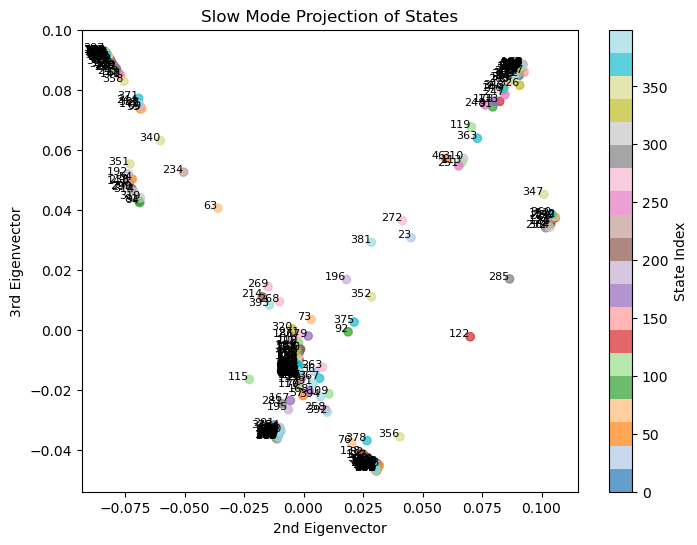

In [11]:
def plot_slow_modes(eigenvectors):
    """
    Plots clusters (states) in the space of the slowest eigenvectors.
    """
    num_clusters = eigenvectors.shape[0]
    cmap = plt.get_cmap('tab20', num_clusters)  # Distinct colors for each cluster
    state_indices = np.arange(num_clusters)  # Cluster indices for coloring

    plt.figure(figsize=(8, 6))
    plt.scatter(eigenvectors[:, 1], eigenvectors[:, 2], c=state_indices, cmap=cmap, alpha=0.7)
    # also print the eigenvalues for each cluster
    for i in range(num_clusters):
        plt.annotate(f"{i}", (eigenvectors[i, 1], eigenvectors[i, 2]), fontsize=8, ha='right')
    plt.xlabel("2nd Eigenvector")
    plt.ylabel("3rd Eigenvector")
    plt.title("Slow Mode Projection of States")
    plt.colorbar(label="State Index")
    plt.show()

# Visualize the slowest modes
plot_slow_modes(eigenvectors)

In [12]:
def plot_eigenvector_timeseries(eigenvectors, eigenvector_index, labels, plot_till=-1):
    # get the eigenvector value for each cluster
    eigenvector_values = np.real(eigenvectors[labels, eigenvector_index])
    print(eigenvector_values.shape)

    # Plot the eigenvector values over time
    plt.figure(figsize=(8, 6))
    plt.plot(eigenvector_values[:plot_till], '-', label='Eigenvector Values')
    plt.xlabel('Frame')
    plt.ylabel('Eigenvector Value')
    plt.title('Eigenvector Values Over Time')
    plt.axhline(0, color='black', linewidth=0.8, linestyle="--")
    plt.axvline(0, color='black', linewidth=0.8, linestyle="--")
    plt.legend()
    plt.grid()
    plt.show()

def print_dihedrals_sorted_by_eigenvector(cluster_centers_transformed, eigenvectors, dihedral_angles, labels, eigenvector_index, plot_contour=True, vmin=-0.5, vmax=0.5, grid_resolution=500):
    """
    Print dihedral angles of cluster centers sorted by projection on a given eigenvector.
    
    Parameters:
    - cluster_centers_transformed: (n_clusters, 4) array (cos/sin representation)
    - eigenvectors: (eigenvectors of the transition matrix)
    - eigenvector_index: index of the eigenvector to use for sorting
    - dihedral_angles: (num_samples, 2) array of original dihedral angles
    - labels: Cluster labels for each sample
    
    Returns:
    - sorted_indices: indices of clusters sorted by the eigenvector
    - sorted_dihedrals: list of dihedral angle centers in sorted order
    """
    eigenvector = eigenvectors[:, eigenvector_index]  # Select the desired eigenvector
    # Each element in the eigenvector corresponds to a cluster index
    cluster_scores = eigenvector.real  # Real part, in case of numerical noise
    sorted_indices = np.argsort(cluster_scores)

    # Compute original dihedral centers (in degrees) for each cluster
    dihedral_centers = []
    for i in range(len(cluster_centers_transformed)):
        members = dihedral_angles[labels == i]
        center = np.mean(members, axis=0)
        dihedral_centers.append(center)

    sorted_dihedrals = [dihedral_centers[i] for i in sorted_indices]

    print("Dihedral Centers sorted by eigenvector projection:")
    for idx in sorted_indices:
        print(f"Cluster {idx}: \tDihedral1 = {dihedral_centers[idx][0]:.2f}, \tDihedral2 = {dihedral_centers[idx][1]:.2f}, \tScore = {cluster_scores[idx]:.4f}")

    
    # Plot if requested
    if plot_contour:
        dihedral_centers = np.array(dihedral_centers)

        # Adjust dihedral angles to (0, 180) if needed
        phi = (dihedral_centers[:, 0])
        psi = (dihedral_centers[:, 1])

        # Create a grid
        grid_x, grid_y = np.meshgrid(
            np.linspace(-180, 180, grid_resolution),
            np.linspace(-180, 180, grid_resolution)
        )

        # Interpolate eigenvector values onto the grid
        grid_z = griddata(
            points=(phi, psi),
            values=cluster_scores,
            xi=(grid_x, grid_y),
            method='cubic',  # smoother interpolation
            fill_value=0.0
        )

        # Plot contour
        plt.figure(figsize=(8, 6))
        contour = plt.contourf(
            grid_x, grid_y, grid_z,
            levels=50, cmap='coolwarm', 
            # vmin=vmin, vmax=vmax
        )
        plt.colorbar(contour, label='Eigenvector Value')
        plt.xlabel('Dihedral 1 (degrees)')
        plt.ylabel('Dihedral 2 (degrees)')
        plt.title('Smoothed Eigenvector Projection (Contour Plot)')
        plt.grid(True)
        # plt.scatter(phi, psi, c='k', s=20, label='Cluster Centers')  # Plot original cluster centers
        plt.legend()
        plt.show()


    else:
        dihedral_centers = np.array(dihedral_centers)
        plt.figure(figsize=(8, 6))
        scatter = plt.scatter(
            (dihedral_centers[:, 0]) ,
            (dihedral_centers[:, 1]),
            c=cluster_scores,
            cmap='coolwarm',
            edgecolor='k',
            s=120,
            # vmin=vmin,
            # vmax=vmax
        )
        plt.colorbar(scatter, label='Eigenvector Value')
        plt.xlabel('Dihedral 1 (degrees)')
        plt.ylabel('Dihedral 2 (degrees)')
        plt.title(f'Cluster Centers Colored by Eigenvector {eigenvector_index}')
        plt.grid(True)
        plt.show()

    return sorted_indices, sorted_dihedrals


Dihedral Centers sorted by eigenvector projection:
Cluster 336: 	Dihedral1 = 173.75, 	Dihedral2 = 65.99, 	Score = -0.0469
Cluster 147: 	Dihedral1 = 166.10, 	Dihedral2 = 69.88, 	Score = -0.0468
Cluster 162: 	Dihedral1 = -104.65, 	Dihedral2 = 76.72, 	Score = -0.0468
Cluster 252: 	Dihedral1 = -124.93, 	Dihedral2 = 68.91, 	Score = -0.0467
Cluster 383: 	Dihedral1 = 174.53, 	Dihedral2 = 80.02, 	Score = -0.0465
Cluster 296: 	Dihedral1 = 170.51, 	Dihedral2 = 58.40, 	Score = -0.0465
Cluster 5: 	Dihedral1 = 166.90, 	Dihedral2 = 77.47, 	Score = -0.0465
Cluster 187: 	Dihedral1 = -167.64, 	Dihedral2 = 76.71, 	Score = -0.0464
Cluster 75: 	Dihedral1 = 175.04, 	Dihedral2 = 72.61, 	Score = -0.0464
Cluster 112: 	Dihedral1 = 155.02, 	Dihedral2 = 62.52, 	Score = -0.0463
Cluster 312: 	Dihedral1 = 163.68, 	Dihedral2 = 62.73, 	Score = -0.0463
Cluster 372: 	Dihedral1 = 34.69, 	Dihedral2 = 86.06, 	Score = -0.0462
Cluster 78: 	Dihedral1 = 35.60, 	Dihedral2 = 60.59, 	Score = -0.0461
Cluster 277: 	Dihedral1 = 157

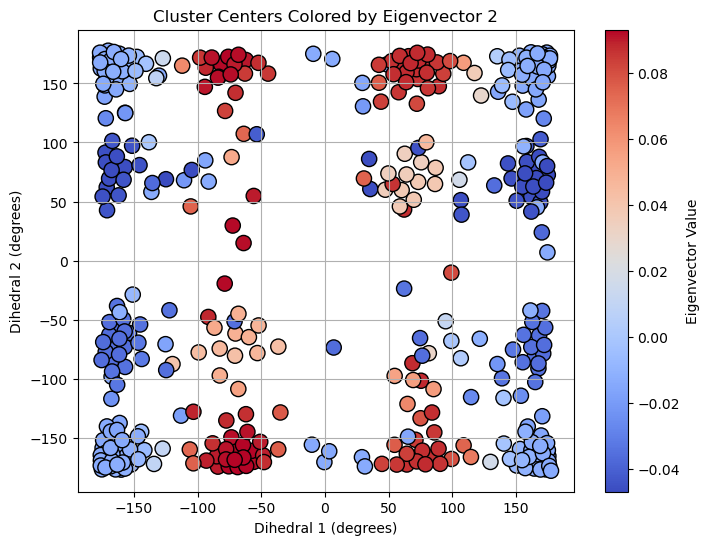

In [13]:
# Choose eigenvector (e.g., 2nd for slowest nontrivial dynamics)
sorted_indices, sorted_dihedrals = print_dihedrals_sorted_by_eigenvector(
    cluster_centers,
    eigenvectors,  
    dihedral_angles,
    labels,
    eigenvector_index=2,
    plot_contour=False,  # Set to False to plot scatter
)


In [14]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.rdMolTransforms import SetDihedralDeg
from openff.toolkit.topology import Molecule
from openff.toolkit.utils import RDKitToolkitWrapper
import numpy as np

def generate_conformations_from_dihedrals(sorted_dihedrals, output_xyz="cluster_centers.xyz"):
    """
    Generate conformations with specific dihedral angles and save as XYZ file.
    
    Parameters:
    - sorted_dihedrals: List of [dihedral1, dihedral2] values (in degrees)
    - output_xyz: Output XYZ file path
    """

    smiles = 'CCCCC'  # Pentane
    off_mol = Molecule.from_smiles(smiles)
    off_mol.generate_conformers(n_conformers=1, toolkit_registry=RDKitToolkitWrapper())
    rdkit_mol = off_mol.to_rdkit()

    xyz_lines = []
    atomic_symbols = [atom.GetSymbol() for atom in rdkit_mol.GetAtoms()]
    num_atoms = len(atomic_symbols)

    for i, (d1, d2) in enumerate(sorted_dihedrals):
        # mol = Chem.Mol(rdkit_mol)
        mol = rdkit_mol

        # Embed and optimize (optional)
        AllChem.EmbedMolecule(mol)
        AllChem.UFFOptimizeMolecule(mol)

        conf = mol.GetConformer()
        
        print(f"Generating conformation {i+1} with dihedrals: {d1:.1f}, {d2:.1f}")

        # Set dihedrals
        SetDihedralDeg(conf, 0, 1, 2, 3, float(d1))
        SetDihedralDeg(conf, 1, 2, 3, 4, float(d2))

        # Write XYZ frame
        xyz_lines.append(f"{num_atoms}\nCluster {i}: Dihedrals = {d1:.1f}, {d2:.1f}")
        for atom_idx in range(num_atoms):
            pos = conf.GetAtomPosition(atom_idx)
            symbol = atomic_symbols[atom_idx]
            xyz_lines.append(f"{symbol} {pos.x:.6f} {pos.y:.6f} {pos.z:.6f}")

    # Save to file
    with open(output_xyz, "w") as f:
        f.write("\n".join(xyz_lines))
    
    print(f"Saved {len(sorted_dihedrals)} conformations to {output_xyz}")


In [15]:
generate_conformations_from_dihedrals(sorted_dihedrals, output_xyz="cluster_centers.xyz")

Generating conformation 1 with dihedrals: 173.8, 66.0
Generating conformation 2 with dihedrals: 166.1, 69.9
Generating conformation 3 with dihedrals: -104.6, 76.7
Generating conformation 4 with dihedrals: -124.9, 68.9
Generating conformation 5 with dihedrals: 174.5, 80.0
Generating conformation 6 with dihedrals: 170.5, 58.4
Generating conformation 7 with dihedrals: 166.9, 77.5
Generating conformation 8 with dihedrals: -167.6, 76.7
Generating conformation 9 with dihedrals: 175.0, 72.6
Generating conformation 10 with dihedrals: 155.0, 62.5
Generating conformation 11 with dihedrals: 163.7, 62.7
Generating conformation 12 with dihedrals: 34.7, 86.1
Generating conformation 13 with dihedrals: 35.6, 60.6
Generating conformation 14 with dihedrals: 157.2, 73.8
Generating conformation 15 with dihedrals: -172.2, 83.2
Generating conformation 16 with dihedrals: -157.2, 79.2
Generating conformation 17 with dihedrals: -169.6, 69.5
Generating conformation 18 with dihedrals: 106.7, 51.2
Generating conf

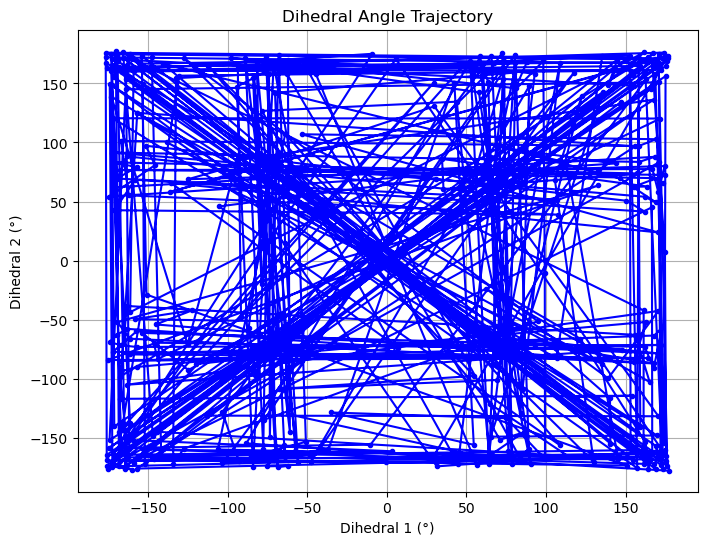

Animation saved to dihedral_trajectory.gif


In [16]:
# plot the timeseries of the dihedrals in the generated trajectory in the dihedral space
sorted_dihedrals_np = np.array(sorted_dihedrals)
plt.figure(figsize=(8, 6))
plt.plot((sorted_dihedrals_np[:, 0]), (sorted_dihedrals_np[:, 1]), marker='o', linestyle='-', color='b', markersize=3)
plt.xlabel("Dihedral 1 (°)")
plt.ylabel("Dihedral 2 (°)")
plt.title("Dihedral Angle Trajectory")
plt.grid(True)
plt.show()

import matplotlib.pyplot as plt
import matplotlib.animation as animation

def animate_dihedral_trajectory(sorted_dihedrals, save_path="dihedral_trajectory.gif", interval=50):
    sorted_dihedrals_np = np.array(sorted_dihedrals)
    x = (sorted_dihedrals_np[:, 0])
    y = (sorted_dihedrals_np[:, 1])

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_xlim(-180, 180)
    ax.set_ylim(-180, 180)
    ax.set_xlabel("Dihedral 1 (°)")
    ax.set_ylabel("Dihedral 2 (°)")
    ax.set_title("Dihedral Angle Trajectory Animation")
    ax.grid(True)

    line, = ax.plot([], [], 'b-', lw=1)
    point, = ax.plot([], [], 'ro', markersize=4)

    def init():
        line.set_data([], [])
        point.set_data([], [])
        return line, point

    def update(frame):
        line.set_data(x[:frame+1], y[:frame+1])
        point.set_data([x[frame]], [y[frame]])  
        return line, point

    ani = animation.FuncAnimation(
        fig, update, frames=len(x),
        init_func=init, blit=True, interval=interval
    )

    ani.save(save_path, writer='pillow')
    plt.close()
    print(f"Animation saved to {save_path}")

# Example usage:
animate_dihedral_trajectory(sorted_dihedrals, save_path="dihedral_trajectory.gif", interval=50)

RUN AFTER LONG TRAJ

In [17]:
# Atom indices for the two main dihedrals in pentane (assuming standard numbering)
dihedral1_atoms = [0, 1, 2, 3]  # First dihedral
dihedral2_atoms = [1, 2, 3, 4]  # Second dihedral

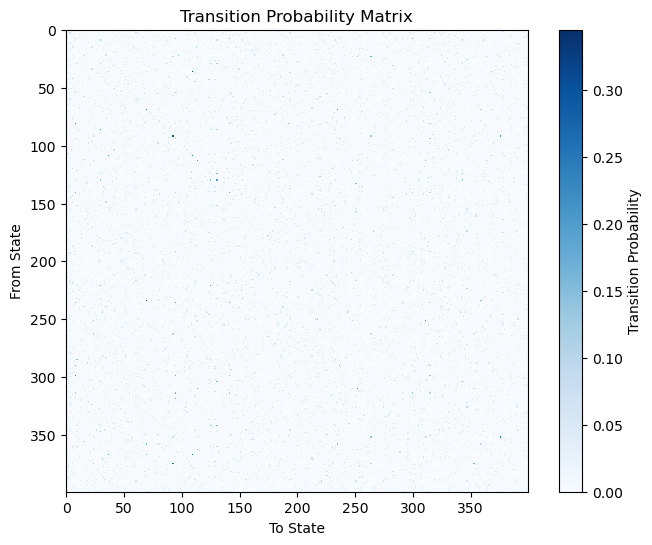

Top eigenvalues (MD, 160 fs lag): [ 1.00000000e+00  9.81545753e-01  9.80462068e-01  9.79560351e-01
  9.77989276e-01  9.60286881e-01  9.53482872e-01  7.68197213e-01
  7.53314582e-01  5.85859315e-01  5.37089226e-01  4.69928899e-01
  4.39021971e-01  3.97925073e-01  3.25427277e-01  3.21220409e-01
  3.18129201e-01  3.13596808e-01  2.78773823e-01  2.59467528e-01
  2.47100227e-01  2.45689329e-01  2.34026348e-01  2.30996268e-01
  2.22026811e-01  2.19336054e-01  2.18843200e-01  2.16524095e-01
  2.02392613e-01  1.97874583e-01  1.57456214e-01  1.52771406e-01
  1.26495176e-01  1.11772725e-01  1.06374770e-01  9.62697575e-02
  9.37497909e-02  8.95211932e-02  8.79661638e-02  8.35350159e-02
  8.29394405e-02  7.89082365e-02  7.63645104e-02  7.26291444e-02
  7.11071983e-02  6.82504016e-02  6.58482912e-02  6.44031675e-02
  6.28296769e-02  6.20218592e-02  6.06162356e-02  5.84293811e-02
  5.65422179e-02  5.59996338e-02  5.20018690e-02  4.98869693e-02
  4.94197303e-02  4.88188649e-02  4.73178686e-02  4.7242

In [18]:
# Load MD trajectory (already assumes the above code is run)
pdb_md = md.load_pdb("pentane_highE.pdb")
traj_md = md.load("trajectory.dcd", top=pdb_md)
# traj_md = traj_md[:312500]

# Compute dihedral angles for MD
angles_md = compute_dihedral_angles(traj_md, dihedral1_atoms, dihedral2_atoms)
transformed_md = transform_angles(angles_md)

# Use previously trained KMeans model from HMC clustering
labels_md = kmeans.predict(transformed_md)

# Build transition matrix from MD trajectory
frame_lag = 1  # 160 fs
P_md = np.zeros((n_clusters, n_clusters))

for i in range(len(labels_md) - frame_lag):
    from_state = labels_md[i]
    to_state = labels_md[i + frame_lag]
    P_md[from_state, to_state] += 1
    P_md[to_state, from_state] += 1  # symmetric transition

# Normalize rows
row_sums = P_md.sum(axis=1, keepdims=True)
P_md = np.divide(P_md, row_sums, where=row_sums > 0)

# Plot
plot_transition_matrix(P_md)

# Eigenvalues
eigenvals_md, _ = compute_eigenmodes(P_md)
print("Top eigenvalues (MD, 160 fs lag):", eigenvals_md[:])


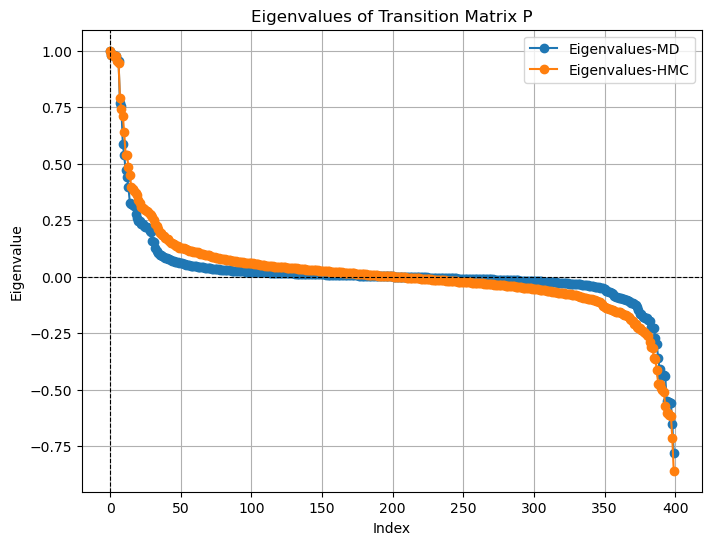

In [19]:
plt.figure(figsize=(8, 6))
plt.plot(np.real(eigenvals_md[:]), 'o-', label='Eigenvalues-MD')
plt.plot(np.real(eigenvalues[:]), 'o-', label='Eigenvalues-HMC')
plt.xlabel('Index')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalues of Transition Matrix P')
plt.axhline(0, color='black', linewidth=0.8, linestyle="--")
plt.axvline(0, color='black', linewidth=0.8, linestyle="--")
plt.legend()
plt.grid()
plt.show()

AFTER SHORT TRAJ


In [20]:
# Atom indices for the two main dihedrals in pentane (assuming standard numbering)
dihedral1_atoms = [0, 1, 2, 3]  # First dihedral
dihedral2_atoms = [1, 2, 3, 4]  # Second dihedral

In [21]:
# Load MD trajectory (already assumes the above code is run)
pdb_md = md.load_pdb("pentane_highE.pdb")
traj_md = md.load("short-trajectory.dcd", top=pdb_md)

# Compute dihedral angles for MD
angles_md = compute_dihedral_angles(traj_md, dihedral1_atoms, dihedral2_atoms)
print(angles_md.shape)

(6250, 2)


(6250,)
[144 222 144 ... 267 114 396]
(6250,)


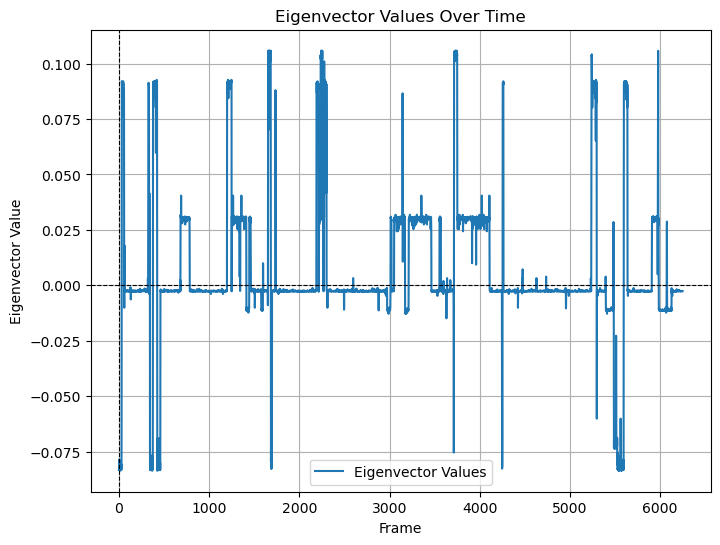

In [22]:
md_labels = kmeans.predict(transform_angles(angles_md))
print(md_labels.shape)
print(md_labels)
plot_eigenvector_timeseries(eigenvectors, 1, md_labels, plot_till=-1)

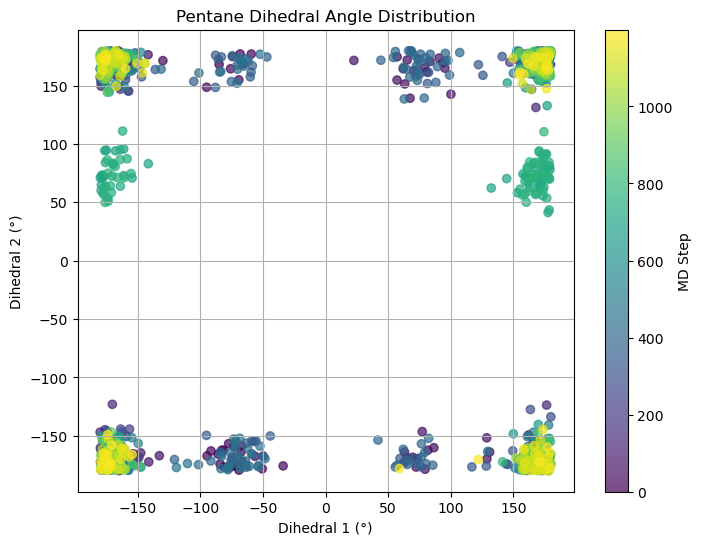

In [23]:
# Plot dihedral angles
plt.figure(figsize=(8, 6))
cutoff = 1200
plt.scatter((angles_md[:cutoff, 0]), (angles_md[:cutoff, 1]), c=np.arange(len(angles_md[:cutoff])), cmap='viridis', alpha=0.7)
plt.colorbar(label="MD Step")
plt.xlabel("Dihedral 1 (°)")
plt.ylabel("Dihedral 2 (°)")
plt.title("Pentane Dihedral Angle Distribution")
plt.grid(True)
plt.show()

SIMULATE TRAJECTORY USING TRANSITION MATRIX

In [24]:
def simulate_markov_chain(P, start_state, num_steps):
    """
    Simulates a Markov chain given a transition matrix P, an initial state, and number of steps.

    Parameters:
    P (numpy.ndarray): Transition probability matrix (n x n).
    start_state (int): Index of the initial state (0-based).
    num_steps (int): Number of steps to simulate.

    Returns:
    list: Sequence of visited states.
    """
    states = [start_state]
    current_state = start_state
    for _ in range(num_steps):
        next_state = np.random.choice(len(P), p=P[current_state])
        states.append(next_state)
        current_state = next_state
    return states

In [25]:
start_state = 144
num_steps = 6250

generated_trajectory = simulate_markov_chain(P, start_state, num_steps)
print("Markov chain trajectory:", generated_trajectory)

Markov chain trajectory: [144, 241, 41, 243, 144, 51, 241, 212, 280, 330, 185, 323, 41, 88, 345, 151, 241, 222, 397, 67, 331, 233, 166, 185, 104, 41, 104, 19, 321, 79, 69, 261, 93, 88, 331, 4, 88, 222, 330, 345, 331, 166, 308, 330, 397, 397, 222, 11, 166, 222, 331, 88, 284, 31, 284, 31, 68, 51, 233, 233, 268, 271, 35, 125, 327, 359, 148, 254, 384, 107, 64, 249, 101, 368, 39, 44, 160, 368, 245, 153, 276, 148, 202, 278, 203, 364, 199, 7, 201, 125, 191, 384, 354, 379, 267, 99, 30, 194, 65, 83, 61, 359, 153, 89, 266, 384, 87, 295, 301, 39, 176, 85, 276, 107, 335, 344, 24, 50, 264, 1, 213, 126, 153, 276, 156, 384, 6, 384, 7, 189, 357, 74, 7, 338, 206, 191, 176, 177, 208, 209, 198, 305, 7, 376, 368, 295, 344, 83, 189, 134, 398, 357, 209, 83, 14, 198, 317, 95, 275, 307, 398, 24, 199, 99, 1, 364, 398, 134, 180, 13, 317, 208, 338, 307, 273, 169, 160, 176, 317, 95, 177, 47, 56, 47, 201, 176, 53, 44, 53, 357, 332, 344, 83, 153, 83, 266, 359, 275, 368, 101, 70, 160, 334, 170, 50, 114, 211, 117, 25

In [26]:
# generate a series of dihedral angles from the generated trajectory
generated_dihedrals = []
for label in generated_trajectory:
    generated_dihedrals.append(dihedral_angles[labels == label][0])
generated_dihedrals = np.array(generated_dihedrals)
print(generated_dihedrals.shape)
print(generated_dihedrals)

generate_conformations_from_dihedrals(generated_dihedrals, output_xyz="P_gen_trajectory.xyz")

(6251, 2)
[[ -66.27556  -175.68134 ]
 [ -65.62338   172.97205 ]
 [ -53.980305 -166.88454 ]
 ...
 [  41.808155 -173.66725 ]
 [ 110.4467   -173.71268 ]
 [  67.916725  168.3133  ]]
Generating conformation 1 with dihedrals: -66.3, -175.7
Generating conformation 2 with dihedrals: -65.6, 173.0
Generating conformation 3 with dihedrals: -54.0, -166.9
Generating conformation 4 with dihedrals: -101.8, 171.2
Generating conformation 5 with dihedrals: -66.3, -175.7
Generating conformation 6 with dihedrals: -82.3, -174.2
Generating conformation 7 with dihedrals: -65.6, 173.0
Generating conformation 8 with dihedrals: -90.6, -170.7
Generating conformation 9 with dihedrals: -76.9, 179.0
Generating conformation 10 with dihedrals: -63.4, -175.8
Generating conformation 11 with dihedrals: -81.7, 176.2
Generating conformation 12 with dihedrals: -78.8, -170.7
Generating conformation 13 with dihedrals: -54.0, -166.9
Generating conformation 14 with dihedrals: -77.9, 169.8
Generating conformation 15 with dihedr

(6251,)


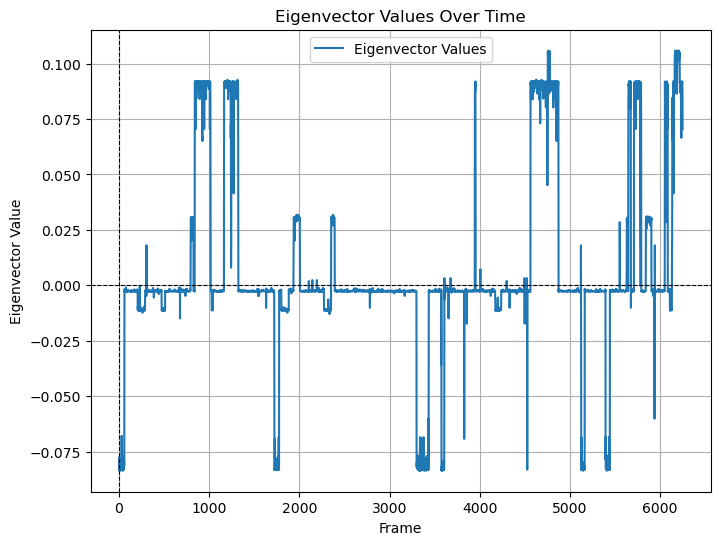

In [27]:
plot_eigenvector_timeseries(eigenvectors, 1, generated_trajectory, plot_till=-1)